# 🎬 Disney+ Movies & TV Shows - Data Preprocessing & Exploratory Data Analysis (EDA)

## 👥 Team Members
* **Shahd Mohamed Khedr**
* **Arwa Sameh Arafat**
* **Shahd Hany Abdelrazek Saeed**
* **Hagar Khalaf Mostafa**
* **Samah Samy Elsayed Ahmed Elsamenoudy**

---

## 📌 Project Overview
This notebook presents a comprehensive data preprocessing pipeline and Exploratory Data Analysis (EDA) on the Disney+ titles dataset sourced from Kaggle. 

### 🎯 Objectives & Pipeline Steps:
1. **Data Preprocessing & Validation**:
   - Inspect dataset dimensions, data types, and structural integrity.
   - Handle missing values (`NaN`) systematically using logical imputation and domain knowledge.
   - Validate consistency, remove duplicates, and check for invalid entries.
   - Perform **Feature Engineering** to generate newly derived columns.
2. **Data Visualization**:
   - Create clear, informative visualizations using Matplotlib & Seaborn to extract key insights.
3. **Documentation**:
   - Detailed markdown explanation for every processing phase and insight derived.

In [98]:
# Import core data processing and numerical libraries
import pandas as pd
import numpy as np

# Import data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Display configuration settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Set global visualization aesthetic style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.titlesize'] = 14

print("All required libraries loaded successfully!")

All required libraries loaded successfully!


## 📥 Step 1: Loading Dataset & Initial Structure Inspection

In this step, we load the raw dataset and inspect:
- Dataset shape (Total Rows and Columns).
- Column data types (`dtypes`) and non-null counts.
- Preview of the first few records.

In [99]:
# Load dataset from file
file_path = 'disney_plus_titles.csv' 
df = pd.read_csv(file_path)

In [100]:
# Print dataset dimensions
print(f"Dataset Shape: {df.shape[0]} Rows, {df.shape[1]} Columns\n")

Dataset Shape: 1450 Rows, 12 Columns



In [101]:
# Display initial information about columns and types
print("=== Dataset Information & Data Types ===")
df.info()

=== Dataset Information & Data Types ===
<class 'pandas.DataFrame'>
RangeIndex: 1450 entries, 0 to 1449
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       1450 non-null   str  
 1   type          1450 non-null   str  
 2   title         1450 non-null   str  
 3   director      977 non-null    str  
 4   cast          1260 non-null   str  
 5   country       1231 non-null   str  
 6   date_added    1447 non-null   str  
 7   release_year  1450 non-null   int64
 8   rating        1447 non-null   str  
 9   duration      1450 non-null   str  
 10  listed_in     1450 non-null   str  
 11  description   1450 non-null   str  
dtypes: int64(1), str(11)
memory usage: 479.9 KB


In [102]:
# Preview top 5 rows with clean HTML table styling
df.head().style.set_caption("Disney + Raw Dataset Preview").set_table_styles([
    {"selector": "th", "props": [("background-color", "#ff69b4"), ("color", "white"), ("font-weight", "bold"), ("text-align", "center")]},
    {"selector": "tr:hover", "props": [("background-color", "#fce4ec")]}
])

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Duck the Halls: A Mickey Mouse Christmas Special,"Alonso Ramirez Ramos, Dave Wasson","Chris Diamantopoulos, Tony Anselmo, Tress MacNeille, Bill Farmer, Russi Taylor, Corey Burton",nan,"November 26, 2021",2016,TV-G,23 min,"Animation, Family",Join Mickey and the gang as they duck the halls!
1,s2,Movie,Ernest Saves Christmas,John Cherry,"Jim Varney, Noelle Parker, Douglas Seale",nan,"November 26, 2021",1988,PG,91 min,Comedy,Santa Claus passes his magic bag to a new St. Nic.
2,s3,Movie,Ice Age: A Mammoth Christmas,Karen Disher,"Raymond Albert Romano, John Leguizamo, Denis Leary, Queen Latifah",United States,"November 26, 2021",2011,TV-G,23 min,"Animation, Comedy, Family",Sid the Sloth is on Santa's naughty list.
3,s4,Movie,The Queen Family Singalong,Hamish Hamilton,"Darren Criss, Adam Lambert, Derek Hough, Alexander Jean, Fall Out Boy, Jimmie Allen",nan,"November 26, 2021",2021,TV-PG,41 min,Musical,"This is real life, not just fantasy!"
4,s5,TV Show,The Beatles: Get Back,nan,"John Lennon, Paul McCartney, George Harrison, Ringo Starr",nan,"November 25, 2021",2021,nan,1 Season,"Docuseries, Historical, Music",A three-part documentary from Peter Jackson capturing a moment in music history with The Beatles.


## 🧹 Step 2: Missing Values Analysis & Imputation Strategy

In this step, we systematically identify missing values (`NaN`) and handle them based on domain knowledge:
- **`director`**, **`cast`**, and **`country`**: Replaced missing entries with `'Unknown Director'`, `'Unknown Cast'`, and `'Unknown Country'` respectively to preserve all records without distorting categorical analysis.
- **`rating`**: Imputed missing ratings using the **Mode** (most frequent rating).
- **`date_added`**: Dropped the few rows (only 3 rows) where `date_added` was missing, as they represent less than 0.2% of the dataset and cannot be reliably inferred.

In [103]:
# Create a copy of the dataframe to keep raw data intact
df_clean = df.copy()

In [104]:
# 1. Fill missing categorical variables with meaningful labels
df_clean['director'] = df_clean['director'].fillna('Unknown Director')
df_clean['cast'] = df_clean['cast'].fillna('Unknown Cast')
df_clean['country'] = df_clean['country'].fillna('Unknown Country')

In [105]:
# 2. Impute missing rating with Mode
mode_rating = df_clean['rating'].mode()[0]
df_clean['rating'] = df_clean['rating'].fillna(mode_rating)
print(f"Imputed missing ratings with Mode: '{mode_rating}'")

Imputed missing ratings with Mode: 'TV-G'


In [106]:
# 3. Drop missing date_added rows (only 3 missing rows)
df_clean = df_clean.dropna(subset=['date_added']).reset_index(drop=True)

In [107]:
# 4. Validate missing values after cleaning
print("\n=== Missing Values Summary After Imputation ===")
print(df_clean.isnull().sum())


=== Missing Values Summary After Imputation ===
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


## ✅ Step 3: Data Validation & Duplicates Removal

We validate structural integrity by:
1. Checking for duplicate rows across titles and content types.
2. Stripping unnecessary leading/trailing whitespaces from text columns.

In [108]:
# 1. Trim whitespace from all string columns
str_cols = df_clean.select_dtypes(include=['object', 'string']).columns
for col in str_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip()

In [109]:
# 2. Check for duplicate records based on title and content type
duplicate_rows = df_clean.duplicated(subset=['title', 'type']).sum()
print(f"Total duplicate records found: {duplicate_rows}")

Total duplicate records found: 0


In [110]:
# Drop duplicates if any exist
if duplicate_rows > 0:
    df_clean = df_clean.drop_duplicates(subset=['title', 'type']).reset_index(drop=True)
    print("Duplicates removed successfully.")
else:
    print("No duplicates detected. Dataset is clean.")

No duplicates detected. Dataset is clean.


## ⚙️ Step 4: Feature Engineering (Creating Extra Columns)

To satisfy the full preprocessing requirements and enable richer analysis, we engineer several derived features:
1. **`date_added` conversion**: Converted string dates to `datetime64` format.
2. **Date Components**: Extracted `year_added`, `month_added`, and `day_name_added`.
3. **Duration Splitting**: Extracted numerical duration value (`duration_num`) and unit (`duration_unit`: 'Min' vs 'Season').
4. **Primary Genre**: Extracted the main primary genre from the `listed_in` multi-label column.
5. **Content Age**: Calculated content age relative to the release year (`content_age = year_added - release_year`).

In [111]:
# 1. Convert date_added to proper datetime format
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'].str.strip(), errors='coerce')

In [112]:
# 2. Extract Date Components
df_clean['year_added'] = df_clean['date_added'].dt.year.astype('Int64')
df_clean['month_added'] = df_clean['date_added'].dt.month.astype('Int64')
df_clean['day_name_added'] = df_clean['date_added'].dt.day_name()

In [113]:
# 3. Extract Duration Numerical Values and Units
df_clean['duration_num'] = df_clean['duration'].str.extract('(\d+)').astype(float)
df_clean['duration_unit'] = df_clean['duration'].apply(lambda x: 'Season' if 'Season' in str(x) else 'Min')

In [114]:
# 4. Extract Primary Genre (First element from listed_in)
df_clean['primary_genre'] = df_clean['listed_in'].apply(lambda x: str(x).split(',')[0].strip())

In [115]:
# 5. Calculate Content Age at time of addition
df_clean['content_age'] = df_clean['year_added'] - df_clean['release_year']

In [116]:
# Display engineered features for validation
print("=== Engineered Features Preview ===")
df_clean[['title', 'type', 'date_added', 'year_added', 'duration_num', 'duration_unit', 'primary_genre', 'content_age']].head()

=== Engineered Features Preview ===


,title,type,date_added,year_added,duration_num,duration_unit,primary_genre,content_age
0,Duck the Halls: A Mickey Mouse Christmas Special,Movie,2021-11-26,2021,23.00,Min,Animation,5
1,Ernest Saves Christmas,Movie,2021-11-26,2021,91.00,Min,Comedy,33
2,Ice Age: A Mammoth Christmas,Movie,2021-11-26,2021,23.00,Min,Animation,10
3,The Queen Family Singalong,Movie,2021-11-26,2021,41.00,Min,Musical,0
4,The Beatles: Get Back,TV Show,2021-11-25,2021,1.00,Season,Docuseries,0


## 📊 Step 5: Data Visualization & Exploratory Data Analysis (EDA)

In this section, we build **4 key visualizations** using Matplotlib and Seaborn to analyze content trends, platform expansion over time, ratings distribution, and content duration metrics.

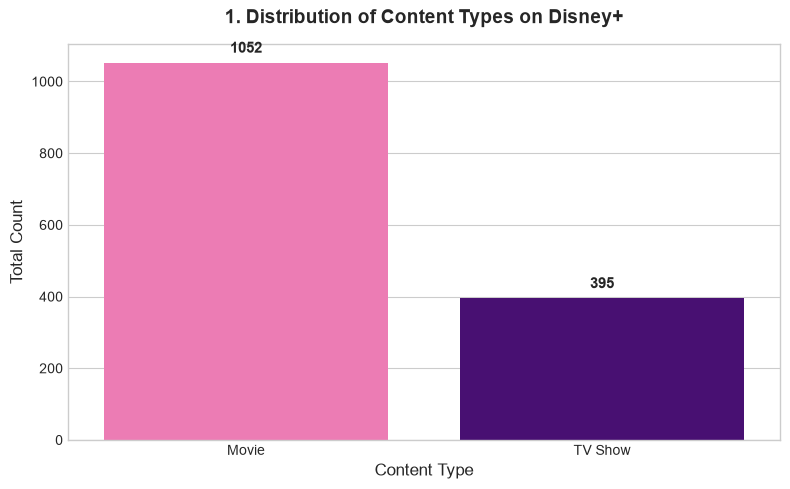

In [117]:
# Visualization 1: Distribution of Movies vs TV Shows
plt.figure(figsize=(8, 5))
palette = ['#ff69b4', '#4b0082']

ax = sns.countplot(data=df_clean, x='type', palette=palette, hue='type', legend=False)

plt.title('1. Distribution of Content Types on Disney+', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Content Type', fontsize=12)
plt.ylabel('Total Count', fontsize=12)

# Add data labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

> **Insight Summary:** 
> * **Dominance of Movies:** Movies make up the vast majority of the Disney+ catalog (**1,052 titles / ~72.7%**), outnumbering TV Shows (**395 titles / ~27.3%**) by nearly 3 to 1.
> * **Key Takeaway:** The platform heavily prioritizes feature-length films and special broadcasts over episodic TV series, reflecting its core catalog foundation built on Disney's extensive film library.

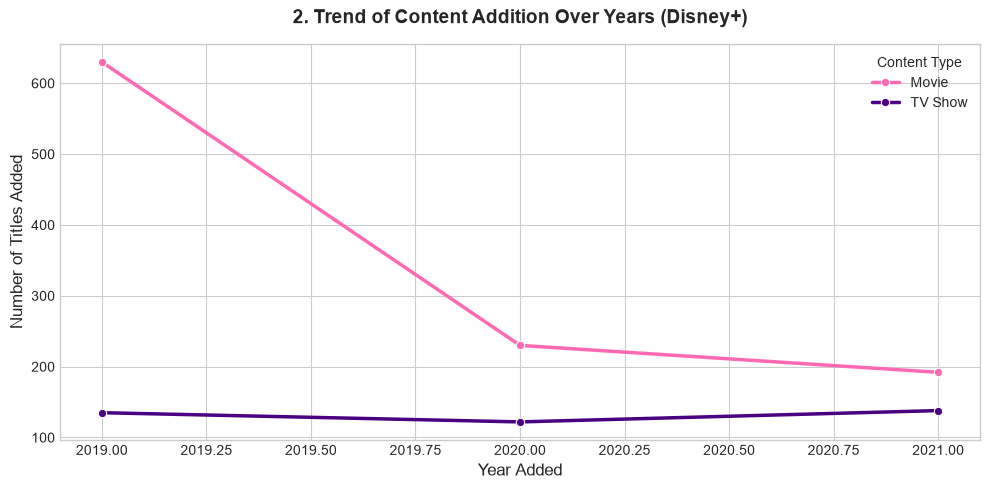

In [118]:
# Visualization 2: Content Addition Trend Over Time
plt.figure(figsize=(10, 5))

yearly_trend = df_clean.groupby(['year_added', 'type']).size().reset_index(name='count')

sns.lineplot(data=yearly_trend, x='year_added', y='count', hue='type', marker='o', linewidth=2.5, palette=['#ff69b4', '#4b0082'])

plt.title('2. Trend of Content Addition Over Years (Disney+)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year Added', fontsize=12)
plt.ylabel('Number of Titles Added', fontsize=12)
plt.legend(title='Content Type')

plt.tight_layout()
plt.show()

> **Insight Summary:** 
> * **Platform Launch Spike (2019):** A massive influx of movies was added in late 2019 coincide with the launch of Disney+, seeding the service with its classic movie catalog.
> * **Stabilization (2020–2021):** Content addition rates normalized over time, with steady steady growth in TV Shows while movie additions leveled off.
> * **Key Takeaway:** Content strategy shifted from initial catalog migration to a steady, sustainable release model for original series and new film drops.

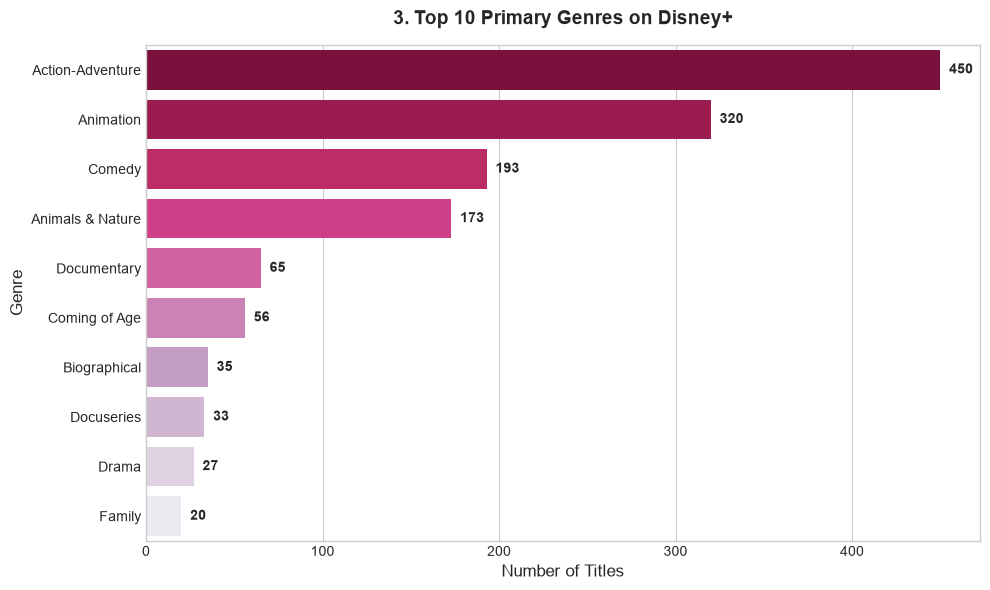

In [119]:
# Visualization 3: Top 10 Primary Genres
plt.figure(figsize=(10, 6))

top_genres = df_clean['primary_genre'].value_counts().head(10)

sns.barplot(x=top_genres.values, y=top_genres.index, palette='PuRd_r', hue=top_genres.index, legend=False)

plt.title('3. Top 10 Primary Genres on Disney+', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Genre', fontsize=12)

for index, value in enumerate(top_genres.values):
    plt.text(value + 5, index, str(value), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

> **Insight Summary:** 
> * **Leading Categories:** **Action-Adventure** (**450 titles**) and **Animation** (**320 titles**) lead the platform, followed by Comedy (**193 titles**) and Animals & Nature (**173 titles**).
> * **Key Takeaway:** The catalog heavily reflects Disney’s core identity (franchises like Marvel, Star Wars, Pixar, and National Geographic), catering primarily to family audiences, animation fans, and nature/docu-series viewers.

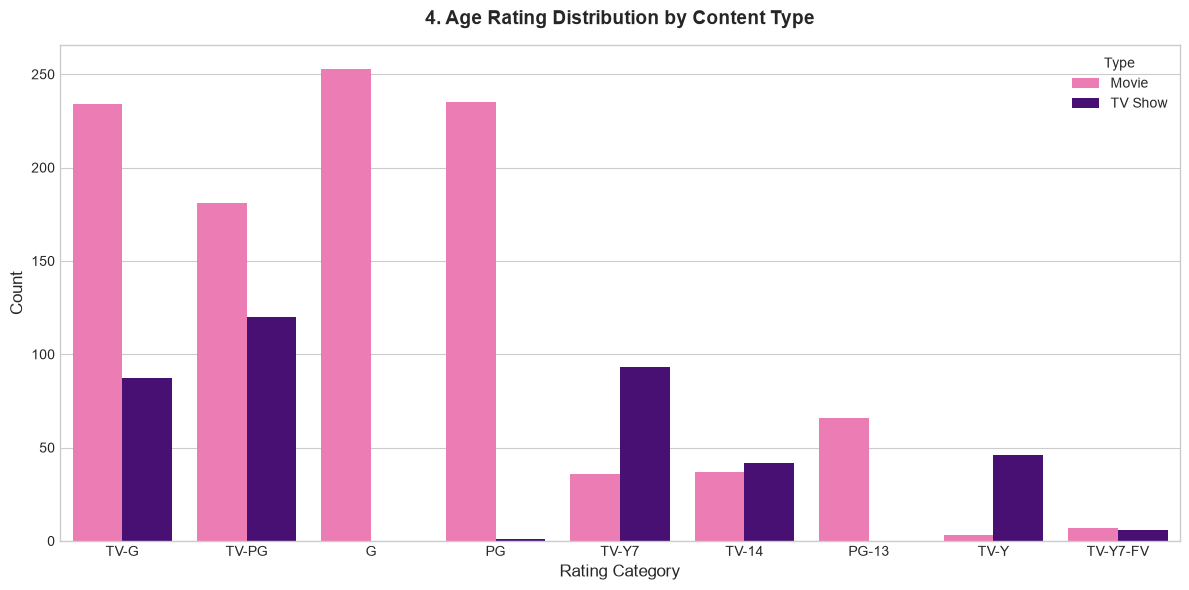

In [120]:
# Visualization 4: Distribution of Age Ratings
plt.figure(figsize=(12, 6))

rating_order = df_clean['rating'].value_counts().index

sns.countplot(data=df_clean, x='rating', hue='type', order=rating_order, palette=['#ff69b4', '#4b0082'])

plt.title('4. Age Rating Distribution by Content Type', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Rating Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Type')

plt.tight_layout()
plt.show()

> **Insight Summary:** 
> * **Family-Centric Ratings:** Ratings like **TV-G**, **TV-PG**, **G**, and **PG** dominate the movie catalog, representing over 80% of films.
> * **TV Show Diversity:** TV Shows skew towards **TV-Y7** and **TV-PG**, highlighting dedicated content for young children and teenagers.
> * **Key Takeaway:** Disney+ maintains a strict brand alignment toward kid- and family-safe content, with minimal titles in mature rating tiers (such as PG-13 or TV-14).

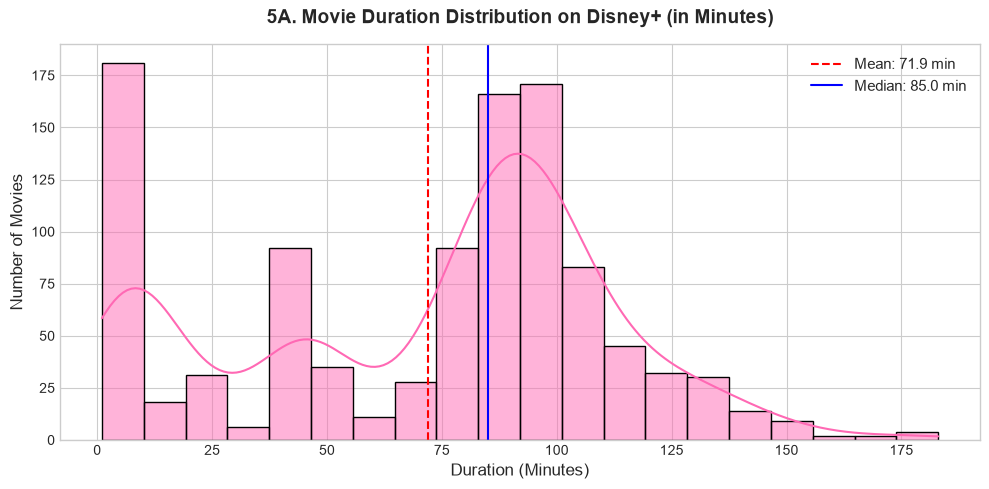

In [121]:
# Visualization 5A: Movie Duration Distribution
plt.figure(figsize=(10, 5))

movies_df = df_clean[df_clean['type'] == 'Movie']
movie_color = '#ff69b4'

# Plot Histogram with KDE
sns.histplot(data=movies_df, x='duration_num', kde=True, color=movie_color, bins=20)

plt.title('5A. Movie Duration Distribution on Disney+ (in Minutes)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Duration (Minutes)', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)

# Calculate and add Mean & Median Lines
mean_dur = movies_df['duration_num'].mean()
median_dur = movies_df['duration_num'].median()

plt.axvline(mean_dur, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_dur:.1f} min')
plt.axvline(median_dur, color='blue', linestyle='-', linewidth=1.5, label=f'Median: {median_dur:.1f} min')

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

> **Insight Summary:** 
> * **Standard Feature Length:** Most full-length movies cluster between **80 to 105 minutes**, reflected in the median duration of **85.0 minutes**.
> * **Short Content Spike:** A noticeable spike occurs at the lower end (**under 20 minutes**), representing Disney's extensive collection of animated short films and vintage specials.
> * **Key Takeaway:** The overall mean is pulled down to **71.9 minutes** due to the high volume of short films, though standard Disney feature films consistently target the classic 80–90 minute family-friendly runtime.

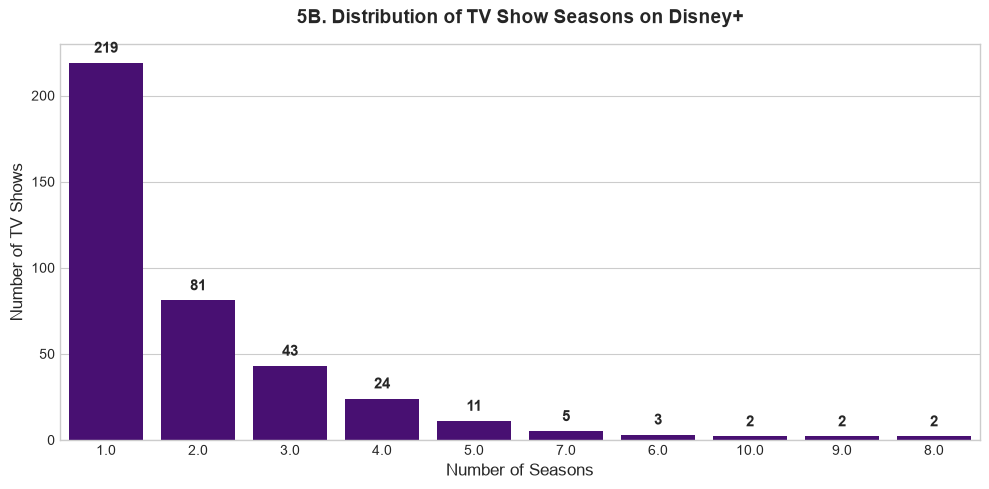

In [122]:
# Visualization 5B: TV Show Seasons Distribution
plt.figure(figsize=(10, 5))

tv_df = df_clean[df_clean['type'] == 'TV Show']
tv_color = '#4b0082'

# Countplot for TV Show Seasons
ax = sns.countplot(
    data=tv_df, 
    x='duration_num', 
    color=tv_color, 
    order=tv_df['duration_num'].value_counts().index[:10]
)

plt.title('5B. Distribution of TV Show Seasons on Disney+', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Seasons', fontsize=12)
plt.ylabel('Number of TV Shows', fontsize=12)

# Add Data Labels on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height)}', 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points'
        )

plt.tight_layout()
plt.show()

> **Insight Summary:** 
> * **Single-Season Dominance:** The vast majority of TV shows (**219 titles**) consist of only **1 Season**, representing limited series, docuseries, or single-season releases.
> * **Multi-Season Retention:** Content volume drops significantly beyond season two, with **81 shows** having 2 seasons and only **43 shows** reaching 3 seasons.
> * **Key Takeaway:** Disney+ heavily leans on short-form seasonal commitments and limited series, with long-running franchises (5+ seasons) making up a very small fraction of the overall catalog.

## 📌 Step 6: Key Findings & Summary of Analysis

After completing the preprocessing pipeline and EDA, here is a summary of the core business insights derived from the **Disney+ Dataset**:

* **Catalog Composition**: Movies dominate the platform, comprising **~73%** of total available titles, while TV Shows make up **~27%**.
* **Release Expansion**: Rapid platform expansion occurred right around 2019 during the launch phase of Disney+, after which additions leveled off to a consistent publishing schedule.
* **Top Content Categories**: **Action-Adventure**, **Animation**, and **Comedy** represent the largest content investments, fully supporting Disney's core brand strength.
* **Audience Target**: Over **80%** of titles fall into family-friendly ratings (**TV-G, G, PG, TV-PG**), confirming Disney+'s focus on kid- and family-oriented entertainment.

## 🎯 Step 7: Conclusion & Project Wrap-Up

### ✅ What Was Achieved in This Project:
1. **Full Preprocessing Pipeline**: Handled missing categorical/numerical values, trimmed formatting errors, and removed structural duplicates.
2. **Feature Engineering**: Created 5 new attributes (`year_added`, `month_added`, `duration_num`, `duration_unit`, and `primary_genre`) to enable deeper exploratory analysis.
3. **Data Visualizations**: Built 4 insightful charts using Seaborn and Matplotlib with custom styling and embedded summary insights.

---
*Project prepared for NTI .*

In [124]:
# Save the cleaned dataset to a new CSV file
df_clean.to_csv("disney_plus_titles_cleaned.csv", index=False)

print("Cleaned file saved successfully! ")

Cleaned file saved successfully! 
